<a href="https://colab.research.google.com/github/douglasbaquiao/materials-solar-ml/blob/main/notebooks/v1_eda_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Materials Informatics — Exploração Comparativa
## Perovskitas Duplas Halogenadas × Kesteritas para Aplicações Fotovoltaicas

**Objetivo:** realizar uma análise exploratória inicial das duas famílias de materiais mais promissoras para um artigo científico em materials informatics, utilizando dados DFT do Materials Project como fonte primária.

**Estrutura do notebook:**
1. Configuração do ambiente e autenticação
2. Estratégia de extração e filtragem — Perovskitas Duplas
3. Estratégia de extração e filtragem — Kesteritas
4. Engenharia de features auxiliares
5. Análise estatística comparativa
6. Visualizações: distribuições, estabilidade e correlações
7. Identificação de candidatos fotovoltaicos
8. Exportação dos dados para análises futuras

---
> **Nota metodológica:** este notebook utiliza exclusivamente dados pré-calculados via DFT disponíveis no Materials Project. Não é necessário acesso a supercomputadores para reproduzir os resultados — a contribuição científica reside na engenharia de descritores, na triagem sistemática e na interpretação física dos padrões encontrados.

## 1. Configuração do Ambiente

### Dependências

O acesso ao Materials Project é feito pelo pacote oficial `mp-api`, que fornece o cliente `MPRester` — uma abstração orientada a objetos sobre a REST API. O `pymatgen` é a biblioteca central de ciência de materiais computacional em Python e é instalado como dependência do `mp-api`.

```bash
pip install mp-api pymatgen
```

### Autenticação

A API exige uma chave de acesso gratuita obtida em [materialsproject.org](https://materialsproject.org). A forma mais segura de usá-la é via variável de ambiente, evitando expor a chave em código versionado:

```bash
# Linux / Mac
export MP_API_KEY="sua_chave_aqui"

# Windows (PowerShell)
$env:MP_API_KEY = "sua_chave_aqui"
```

Se preferir testar rapidamente, substitua `os.environ.get(...)` diretamente pela string da chave — mas não faça isso em repositórios públicos.

In [1]:
!pip install mp-api pymatgen pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 13.7 MB/s eta 0:00:00

In [2]:
from google.colab import userdata

MP_API_KEY = userdata.get("MP_API_KEY")

In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from mp_api.client import MPRester

# Configuração global de plots
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


# ── Paleta de cores consistente para as duas famílias ─────────────────────────
# Usar cores distintas e acessíveis para daltônicos
CORES = {
    "perovskita": "#E07B54",  # laranja-terracota
    "kesterita":  "#4A90D9",  # azul-aço
}

print("Ambiente configurado com sucesso.")
print(f"Chave carregada: {'via variável de ambiente' if os.environ.get('MP_API_KEY') else 'ATENÇÃO — use variável de ambiente'}")

Ambiente configurado com sucesso.
Chave carregada: ATENÇÃO — use variável de ambiente


## 2. Constantes Físicas e Campos da API

### Janela fotovoltaica de Shockley-Queisser

O limite teórico de eficiência de uma célula solar de junção simples (limite de Shockley-Queisser) é maximizado para materiais com band gap entre **1.0 e 1.8 eV**, com pico próximo a 1.34 eV (valor do GaAs). Materiais com gap menor absorvem mais fótons, mas perdem energia por termalização; materiais com gap maior perdem fótons de baixa energia.

> **Conexão com banda intermediária:** materiais com banda intermediária (IBSC) contornam parcialmente esse limite ao criar um segundo canal de absorção sub-gap. O gap efetivo do material hospedeiro pode ser maior que 1.8 eV, desde que a banda intermediária permita absorção em cascata. Isso amplia o espaço de candidatos relevantes — um ponto de diferenciação importante para o artigo.

### Campos extraídos da API

O endpoint `materials.summary` agrega as propriedades mais usadas em triagem computacional. Abaixo estão os campos selecionados e sua justificativa física:

In [6]:
# ── Limites da janela fotovoltaica (Shockley-Queisser) ───────────────────────
PV_GAP_MIN = 1.0   # eV — abaixo disso a termalização domina as perdas
PV_GAP_MAX = 1.8   # eV — acima disso muitos fótons solares não são absorvidos

# Para IBSC, podemos explorar uma janela estendida (o gap do hospedeiro pode ser maior)
IBSC_GAP_MAX = 2.6  # eV — limite superior para materiais candidatos a IBSC

# ── Limiar de estabilidade termodinâmica ─────────────────────────────────────
# Materiais com energy_above_hull < 0.05 eV/átomo são considerados "quasi-estáveis"
# (podem ser sintetizáveis com condições especiais de temperatura/pressão)
HULL_THRESHOLD = 0.05  # eV/átomo

# ── Campos a extrair do endpoint summary ─────────────────────────────────────
CAMPOS = [
    # Identificação
    "material_id",           # ID único no MP (ex: mp-149)
    "formula_pretty",        # Fórmula reduzida (ex: SiO2)
    "chemsys",               # Sistema químico (ex: Si-O)
    # Estrutura
    "nelements",             # Nº de elementos distintos — usado no filtro de extração
    "nsites",                # Nº de sítios na célula unitária
    "volume",                # Volume da célula (Ų)
    "density",               # Densidade (g/cm³)
    "symmetry",              # Objeto com crystal_system, symbol, number
    # Propriedades eletrônicas
    "band_gap",              # Gap de banda (eV) — calculado via DFT-PBE (subestimado ~30%)
    "is_gap_direct",         # True se gap direto — crucial para eficiência de absorção óptica
    "is_metal",              # True se metal (band_gap = 0)
    # Termodinâmica
    "energy_per_atom",       # Energia DFT total por átomo (eV)
    "formation_energy_per_atom",  # Energia de formação em relação aos elementos puros (eV/átomo)
    "energy_above_hull",     # Distância ao convex hull de estabilidade (eV/átomo)
    "is_stable",             # True se está no hull (energy_above_hull = 0)
    # Magnetismo
    "total_magnetization",   # Magnetização total (µB/célula)
    "ordering",              # FM, AFM, FiM ou NM
    # Metadados
    "elements",              # Lista de elementos presentes
]

# Mostrar tabela de referência
info = {
    "Campo":       ["band_gap", "is_gap_direct", "formation_energy_per_atom",
                    "energy_above_hull", "is_stable", "density", "nsites", "ordering"],
    "Unidade":     ["eV", "bool", "eV/átomo", "eV/átomo", "bool", "g/cm³", "—", "str"],
    "Relevância":  [
        "Triagem PV principal — janela 1.0–1.8 eV",
        "Gap direto = absorção óptica eficiente (sem fônon)",
        "Estabilidade química — negativo indica composto favorável",
        "Facilidade de sintetização — <0.05 eV/átomo = quasi-estável",
        "True = no convex hull (termod. estável)",
        "Proxy de nível de compactação e tipo de ligação",
        "Tamanho da célula unitária",
        "Ferromagnético / Antiferromagnético / Não-magnético",
    ]
}
print(pd.DataFrame(info).to_string(index=False))

                    Campo  Unidade                                                  Relevância
                 band_gap       eV                    Triagem PV principal — janela 1.0–1.8 eV
            is_gap_direct     bool          Gap direto = absorção óptica eficiente (sem fônon)
formation_energy_per_atom eV/átomo   Estabilidade química — negativo indica composto favorável
        energy_above_hull eV/átomo Facilidade de sintetização — <0.05 eV/átomo = quasi-estável
                is_stable     bool                     True = no convex hull (termod. estável)
                  density    g/cm³             Proxy de nível de compactação e tipo de ligação
                   nsites        —                                  Tamanho da célula unitária
                 ordering      str         Ferromagnético / Antiferromagnético / Não-magnético


## 3. Extração — Perovskitas Duplas Halogenadas (A₂B'B''X₆)

### Estrutura e motivação

Double perovskites halogenadas têm fórmula geral **A₂B'B''X₆**, onde:
- **A** = cátion monovalente (Cs⁺, Rb⁺, K⁺)
- **B', B''** = dois metais de valências complementares (ex: Ag⁺ e Bi³⁺)
- **X** = haleto (F⁻, Cl⁻, Br⁻, I⁻)

A motivação para estudar essa família é dupla: (1) são livres de chumbo — eliminando toxicidade das perovskitas convencionais — e (2) a combinação de dois cátions B diferentes cria um espaço composicional enorme ainda pouco explorado, com potencial para estados eletrônicos intermediários gerados por hibridização de orbitais d dos dois metais.

### Estratégia de filtro na API

O Materials Project não tem um campo direto "tipo de estrutura = double perovskite". Portanto, usamos uma combinação de filtros composicionais como proxy:
- `nelements = 4` — exatamente 4 elementos distintos (A, B', B'', X)
- Presença obrigatória de um haleto (F, Cl, Br ou I)
- `band_gap` entre 0 e 4 eV — exclui metais puros e isolantes extremos
- `nsites ≤ 40` — remove supercélulas artificialmente grandes

> **Limitação conhecida:** esse filtro captura compostos quaternários com haleto que não são necessariamente double perovskites — alguns podem ter estrutura diferente. Uma triagem mais rigorosa exigiria verificar o grupo espacial (Fm-3m para o protótipo cúbico) ou usar pymatgen para comparar com a estrutura do protótipo. Isso será um refinamento natural na próxima iteração.

In [7]:
def docs_para_df(docs):
    """
    Converte a lista de objetos Summary retornados pela API em DataFrame pandas.
    O objeto symmetry é um sub-objeto — extraímos seus campos manualmente.
    """
    registros = []
    for d in docs:
        sym = d.symmetry if d.symmetry else None
        registros.append({
            "material_id":               d.material_id,
            "formula":                   d.formula_pretty,
            "chemsys":                   d.chemsys,
            "nelements":                 d.nelements,
            "nsites":                    d.nsites,
            "volume":                    d.volume,
            "density":                   d.density,
            "band_gap":                  d.band_gap,
            "is_gap_direct":             d.is_gap_direct,
            "is_metal":                  d.is_metal,
            "energy_above_hull":         d.energy_above_hull,
            "formation_energy_per_atom": d.formation_energy_per_atom,
            "is_stable":                 d.is_stable,
            "crystal_system":            getattr(sym, "crystal_system", None),
            "spacegroup_symbol":         getattr(sym, "symbol", None),
            "spacegroup_number":         getattr(sym, "number", None),
            "total_magnetization":       d.total_magnetization,
            "ordering":                  d.ordering,
        })
    return pd.DataFrame(registros)


# ── Extração ──────────────────────────────────────────────────────────────────
haletos = ["F", "Cl", "Br", "I"]
todos_perovskitas = []

with MPRester(MP_API_KEY) as mpr:
    for haleto in haletos:
        docs = mpr.materials.summary.search(
            elements=[haleto],
            nelements=(4, 4),
            band_gap=(0.0, 4.0),
            fields=CAMPOS,
        )
        todos_perovskitas.extend(docs)
        print(f"  Haleto {haleto}: {len(docs):>5} materiais")

print(f"Total antes da filtragem: {len(todos_perovskitas)}")

Retrieving SummaryDoc documents:   0%|          | 0/3899 [00:00<?, ?it/s]

  Haleto F:  3899 materiais


Retrieving SummaryDoc documents:   0%|          | 0/1937 [00:00<?, ?it/s]

  Haleto Cl:  1937 materiais


Retrieving SummaryDoc documents:   0%|          | 0/954 [00:00<?, ?it/s]

  Haleto Br:   954 materiais


Retrieving SummaryDoc documents:   0%|          | 0/875 [00:00<?, ?it/s]

  Haleto I:   875 materiais
Total antes da filtragem: 7665


In [8]:
# ── Conversão e filtro de nsites ─────────────────────────────────────────────
df_p = docs_para_df(todos_perovskitas)

# Remove supercélulas grandes (nsites > 40 indica célula convencional expandida
# artificialmente — não representa um composto novo)
df_p = df_p[df_p["nsites"] <= 40].copy()

# Remove duplicatas (um material com dois haletos diferentes não existe,
# mas a mesma query pode retornar o mesmo mp-id se houver sobreposição)
df_p = df_p.drop_duplicates(subset="material_id").reset_index(drop=True)

print(f"Pervovskitas Duplas após filtragem: {len(df_p)} materiais")
print(f"\nPrimeiras linhas:")
df_p[["material_id","formula","band_gap","is_gap_direct",
      "energy_above_hull","crystal_system"]].head(10)

Pervovskitas Duplas após filtragem: 6033 materiais

Primeiras linhas:


,material_id,formula,band_gap,is_gap_direct,energy_above_hull,crystal_system
0,mp-1176847,Li8CoO5F,1.7086,True,0.029466,Triclinic
1,mp-1177759,Li2VO2F,0.0883,False,0.069641,Triclinic
2,mp-1223546,KCrO3F,2.6876,False,0.014273,Triclinic
3,mp-1233358,CaV6O11F,0.4538,False,0.208105,Triclinic
4,mp-1233721,MgV6O11F,0.8228,False,0.195820,Triclinic
5,mp-1233816,CaV6O11F,1.0176,False,0.201645,Triclinic
6,mp-1234235,CaV6O11F,1.1967,False,0.204978,Triclinic
7,mp-1234598,CaV6O11F,0.7215,False,0.251960,Triclinic
8,mp-1235307,LiV6O11F,0.6341,False,0.124992,Triclinic
9,mp-1235579,LiV6O11F,0.8069,False,0.125478,Triclinic


## 4. Extração — Kesteritas e Quaternários A₂BCX₄

### Estrutura e motivação

Kesteritas têm fórmula geral **A₂BCX₄**, com o protótipo clássico sendo **Cu₂ZnSnS₄ (CZTS)**. O apelo principal é composto exclusivamente de elementos abundantes na crosta terrestre e não tóxicos. A estrutura deriva da calcopirita por substituição ordenada no sítio catiônico.

Eficiências certificadas já superaram 14%, mas permanecem distantes do limite de Shockley-Queisser para o gap típico de ~1.5 eV — indicando que há espaço para otimização composicional, que é exatamente onde ML pode contribuir.

### Estratégia de filtro

Análoga à das perovskitas, mas usando calcogenetos (S ou Se) como marcador:
- `nelements = 4`
- Presença obrigatória de S ou Se
- `band_gap` entre 0 e 3.5 eV
- `nsites ≤ 50`

> **Nota:** o filtro captura compostos quaternários com calcogeneto em geral, não apenas kesteritas em sentido estrito. Compostos com estrutura de espinélio, famatinita ou estannita também serão incluídos — o que é desejável para uma exploração ampla.

In [9]:
calcogenetos = ["S", "Se"]
todos_kesteritas = []

with MPRester(MP_API_KEY) as mpr:
    for calc in calcogenetos:
        docs = mpr.materials.summary.search(
            elements=[calc],
            nelements=(4, 4),
            band_gap=(0.0, 3.5),
            fields=CAMPOS,
        )
        todos_kesteritas.extend(docs)
        print(f"  Calcogeneto {calc}: {len(docs):>5} materiais")

print(f"\nTotal antes da filtragem: {len(todos_kesteritas)}")

Retrieving SummaryDoc documents:   0%|          | 0/3706 [00:00<?, ?it/s]

  Calcogeneto S:  3706 materiais


Retrieving SummaryDoc documents:   0%|          | 0/1870 [00:00<?, ?it/s]

  Calcogeneto Se:  1870 materiais

Total antes da filtragem: 5576


In [10]:
df_k = docs_para_df(todos_kesteritas)
df_k = df_k[df_k["nsites"] <= 50].copy()
df_k = df_k.drop_duplicates(subset="material_id").reset_index(drop=True)

print(f"Kesteritas após filtragem: {len(df_k)} materiais")
print(f"\nPrimeiras linhas:")
df_k[["material_id","formula","band_gap","is_gap_direct",
      "energy_above_hull","crystal_system"]].head(10)

Kesteritas após filtragem: 4367 materiais

Primeiras linhas:


,material_id,formula,band_gap,is_gap_direct,energy_above_hull,crystal_system
0,mp-1046702,MgCrSF5,1.2534,False,0.236260,Triclinic
1,mp-1046709,ZnCrSF5,1.2455,False,0.198526,Triclinic
2,mp-1046747,MgVSF5,0.2898,False,0.379020,Triclinic
3,mp-1101433,TiCrSO8,1.7158,False,0.034273,Triclinic
4,mp-1180145,NiH12SO9,0.3796,False,0.739790,Triclinic
5,mp-1210679,Ni3H6SO3,2.2922,False,0.800444,Triclinic
6,mp-1224760,Fe2AsSO9,0.0527,False,0.148878,Triclinic
7,mp-1237012,Ni3H6SO3,0.9577,False,0.747720,Triclinic
8,mp-1323771,MgCrSF5,0.0512,False,3.091792,Triclinic
9,mp-1106012,NaMgSO7,0.0991,True,0.482033,Monoclinic


## 5. Engenharia de Features Auxiliares

Além dos campos brutos da API, criamos colunas derivadas que serão úteis tanto na EDA quanto nos modelos de ML da próxima fase.

| Feature derivada | Fórmula | Justificativa |
|---|---|---|
| `site_density` | nsites / volume | Proxy de compacidade estrutural — correlaciona com tipo de ligação |
| `is_pv_candidate` | gap ∈ [1.0, 1.8] e não-metal | Flag de candidato PV para janela Shockley-Queisser |
| `is_ibsc_candidate` | gap ∈ [1.8, 2.6] e não-metal | Janela estendida para candidatos a IBSC |
| `near_hull` | energy_above_hull < 0.05 eV/átomo | Proxy de sintetizabilidade |
| `gap_category` | categórico derivado do gap | Útil para classificação e visualização |

A separação entre candidatos PV convencionais e IBSC é especialmente relevante dado seu background — materiais com gap maior que 1.8 eV que seriam descartados numa triagem padrão podem ser exatamente os mais interessantes para o mecanismo de banda intermediária.

In [11]:
def adicionar_features(df):
    df = df.copy()

    # ── Densidade de sítios ───────────────────────────────────────────────────
    # Representa quantos átomos por unidade de volume — correlaciona com
    # compacidade e pode ser proxy do tipo de ligação (iônica vs covalente)
    df["site_density"] = df["nsites"] / df["volume"]

    # ── Candidatos fotovoltaicos (janela clássica S-Q) ────────────────────────
    df["is_pv_candidate"] = (
        (df["band_gap"] >= PV_GAP_MIN) &
        (df["band_gap"] <= PV_GAP_MAX) &
        (~df["is_metal"])
    )

    # ── Candidatos para IBSC (gap estendido) ──────────────────────────────────
    # Materiais com gap entre 1.8 e 2.6 eV podem hospedar banda intermediária
    # se tiverem estados dentro do gap por dopagem ou defeitos intrínsecos
    df["is_ibsc_candidate"] = (
        (df["band_gap"] > PV_GAP_MAX) &
        (df["band_gap"] <= IBSC_GAP_MAX) &
        (~df["is_metal"])
    )

    # ── Quasi-estabilidade termodinâmica ──────────────────────────────────────
    df["near_hull"] = df["energy_above_hull"] < HULL_THRESHOLD

    # ── Categoria de gap (para visualização e classificação) ──────────────────
    def categorizar_gap(row):
        if row["is_metal"]:
            return "Metal"
        elif row["band_gap"] < PV_GAP_MIN:
            return f"Gap estreito (<{PV_GAP_MIN} eV)"
        elif row["band_gap"] <= PV_GAP_MAX:
            return "Janela PV (1.0–1.8 eV)"
        elif row["band_gap"] <= IBSC_GAP_MAX:
            return "Janela IBSC (1.8–2.6 eV)"
        else:
            return f"Gap largo (>{IBSC_GAP_MAX} eV)"

    df["gap_category"] = df.apply(categorizar_gap, axis=1)

    return df


df_p = adicionar_features(df_p)
df_k = adicionar_features(df_k)

# Visão rápida das novas features
print("Double Perovskites — distribuição de gap_category:")
print(df_p["gap_category"].value_counts().to_string())
print("\nKesteritas — distribuição de gap_category:")
print(df_k["gap_category"].value_counts().to_string())

Double Perovskites — distribuição de gap_category:
gap_category
Metal                       1620
Gap estreito (<1.0 eV)      1550
Janela PV (1.0–1.8 eV)      1052
Gap largo (>2.6 eV)          906
Janela IBSC (1.8–2.6 eV)     905

Kesteritas — distribuição de gap_category:
gap_category
Metal                       1576
Gap estreito (<1.0 eV)      1307
Janela PV (1.0–1.8 eV)       720
Janela IBSC (1.8–2.6 eV)     511
Gap largo (>2.6 eV)          253


## 6. Análise Estatística Comparativa

Antes de qualquer visualização, é importante ter os números em mãos. Estatísticas descritivas revelam assimetrias nas distribuições, outliers e diferenças de escala entre as famílias — tudo isso influencia as escolhas de pré-processamento para ML (normalização, remoção de outliers, etc.).

In [12]:
metricas = [
    "band_gap", "formation_energy_per_atom",
    "energy_above_hull", "density", "nsites", "volume", "site_density"
]

print("=" * 90)
print("ESTATÍSTICAS DESCRITIVAS — PEROVSKITAS DUPLAS")
print("=" * 90)
print(df_p[metricas].describe().round(3).to_string())

print("\n" + "=" * 90)
print("ESTATÍSTICAS DESCRITIVAS — KESTERITAS")
print("=" * 90)
print(df_k[metricas].describe().round(3).to_string())

ESTATÍSTICAS DESCRITIVAS — PEROVSKITAS DUPLAS
       band_gap  formation_energy_per_atom  energy_above_hull   density    nsites    volume  site_density
count  6033.000                   6033.000           6033.000  6033.000  6033.000  6033.000      6033.000
mean      1.171                     -1.897              0.200     3.926    18.770   358.100         0.059
std       1.162                      0.913              0.413     1.152     9.254   225.125         0.024
min       0.000                     -4.066              0.000     0.342     4.000    38.955         0.005
25%       0.000                     -2.556              0.019     3.196    10.000   213.395         0.037
50%       0.898                     -2.050              0.087     3.850    18.000   293.815         0.058
75%       2.041                     -1.397              0.188     4.421    25.000   434.439         0.081
max       3.999                      5.475              6.659     9.353    40.000  2070.509         0.178


In [13]:
# ── Sumário de candidatos ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMÁRIO DE CANDIDATOS")
print("=" * 60)

categorias = [
    ("Candidatos PV (gap 1.0–1.8 eV)",   "is_pv_candidate"),
    ("Candidatos IBSC (gap 1.8–2.6 eV)", "is_ibsc_candidate"),
    ("Termod. estáveis (hull = 0)",       "is_stable"),
    ("Quasi-estáveis (hull < 50 meV)",    "near_hull"),
    ("Gap direto (não-metais)",           None),   # tratado separado
]

for descricao, col in categorias:
    print(f"\n  {descricao}")
    for familia, df in [("Perovskitas", df_p), ("Kesteritas", df_k)]:
        if col:
            n   = df[col].sum()
            pct = 100 * n / len(df)
        else:
            sub = df[~df["is_metal"]]
            n   = sub["is_gap_direct"].sum()
            pct = 100 * n / len(sub)
        print(f"    {familia:15s}: {n:>4} / {len(df):>4}  ({pct:5.1f}%)")


SUMÁRIO DE CANDIDATOS

  Candidatos PV (gap 1.0–1.8 eV)
    Perovskitas    : 1052 / 6033  ( 17.4%)
    Kesteritas     :  720 / 4367  ( 16.5%)

  Candidatos IBSC (gap 1.8–2.6 eV)
    Perovskitas    :  905 / 6033  ( 15.0%)
    Kesteritas     :  511 / 4367  ( 11.7%)

  Termod. estáveis (hull = 0)
    Perovskitas    :  955 / 6033  ( 15.8%)
    Kesteritas     : 1134 / 4367  ( 26.0%)

  Quasi-estáveis (hull < 50 meV)
    Perovskitas    : 2159 / 6033  ( 35.8%)
    Kesteritas     : 2300 / 4367  ( 52.7%)

  Gap direto (não-metais)
    Perovskitas    :  941 / 6033  ( 21.3%)
    Kesteritas     :  835 / 4367  ( 29.9%)


## 7. Visualizações

### 7.1 Distribuição de Band Gap

O histograma com KDE sobreposto é o ponto de partida natural — revela a forma da distribuição (unimodal? bimodal?), a proporção de metais, e visualmente quanto de cada família cai na janela fotovoltaica.

**Interpretação esperada:**
- Double perovskites halogenadas tendem a ter gaps maiores (2–4 eV) porque os haletos são muito eletronegativos, abrindo gaps largos
- Kesteritas tendem a se concentrar em 1.0–2.0 eV — mais naturalmente alinhadas com a janela PV

> **Atenção técnica:** o DFT-PBE subestima band gaps em ~30–50% para semicondutores. Os valores do Materials Project são DFT-PBE por padrão. Para gaps mais precisos, o MP fornece correções HSE06 para alguns materiais — um refinamento a considerar para os candidatos finais.

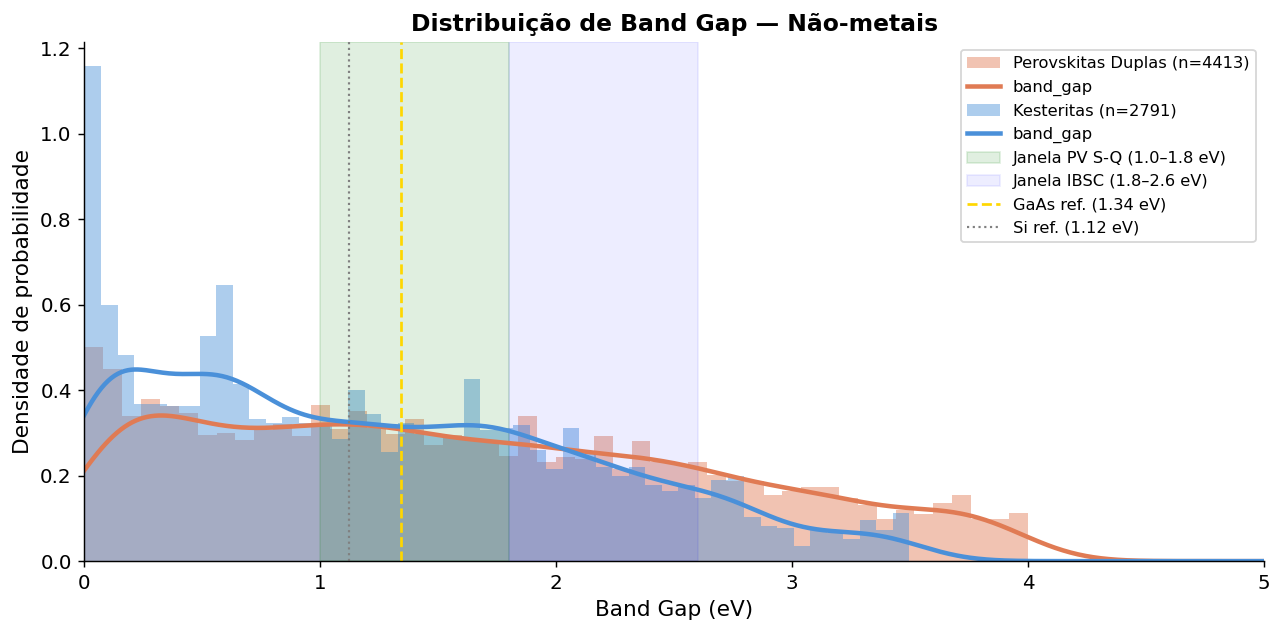

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

for label, df, cor in [
    ("Perovskitas Duplas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]:
    dados = df.loc[~df["is_metal"], "band_gap"].dropna()
    ax.hist(dados, bins=50, alpha=0.45, color=cor, density=True, label=f"{label} (n={len(dados)})")
    dados.plot.kde(ax=ax, color=cor, linewidth=2.5)

# Janela Shockley-Queisser
ax.axvspan(PV_GAP_MIN, PV_GAP_MAX, alpha=0.12, color="green", label="Janela PV S-Q (1.0–1.8 eV)")
# Janela IBSC estendida
ax.axvspan(PV_GAP_MAX, IBSC_GAP_MAX, alpha=0.07, color="blue", label="Janela IBSC (1.8–2.6 eV)")
# Referência GaAs
ax.axvline(1.34, color="gold", linestyle="--", linewidth=1.5, label="GaAs ref. (1.34 eV)")
# Referência Si
ax.axvline(1.12, color="gray", linestyle=":", linewidth=1.2, label="Si ref. (1.12 eV)")

ax.set_xlabel("Band Gap (eV)", fontsize=12)
ax.set_ylabel("Densidade de probabilidade", fontsize=12)
ax.set_title("Distribuição de Band Gap — Não-metais", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig("fig1_distribuicao_gap.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Estabilidade Termodinâmica

O `energy_above_hull` é provavelmente a variável mais importante para triagem computacional: ele mede a distância de um composto ao convex hull de fases estáveis no espaço composicional. Materiais com hull = 0 são termodinamicamente estáveis (existem de fato na natureza ou foram sintetizados). Materiais com hull até ~50–100 meV/átomo são considerados meta-estáveis e potencialmente sintetizáveis sob certas condições.

Este histograma revela a "saúde termodinâmica" do conjunto — quantos materiais realmente temos chance de sintetizar.

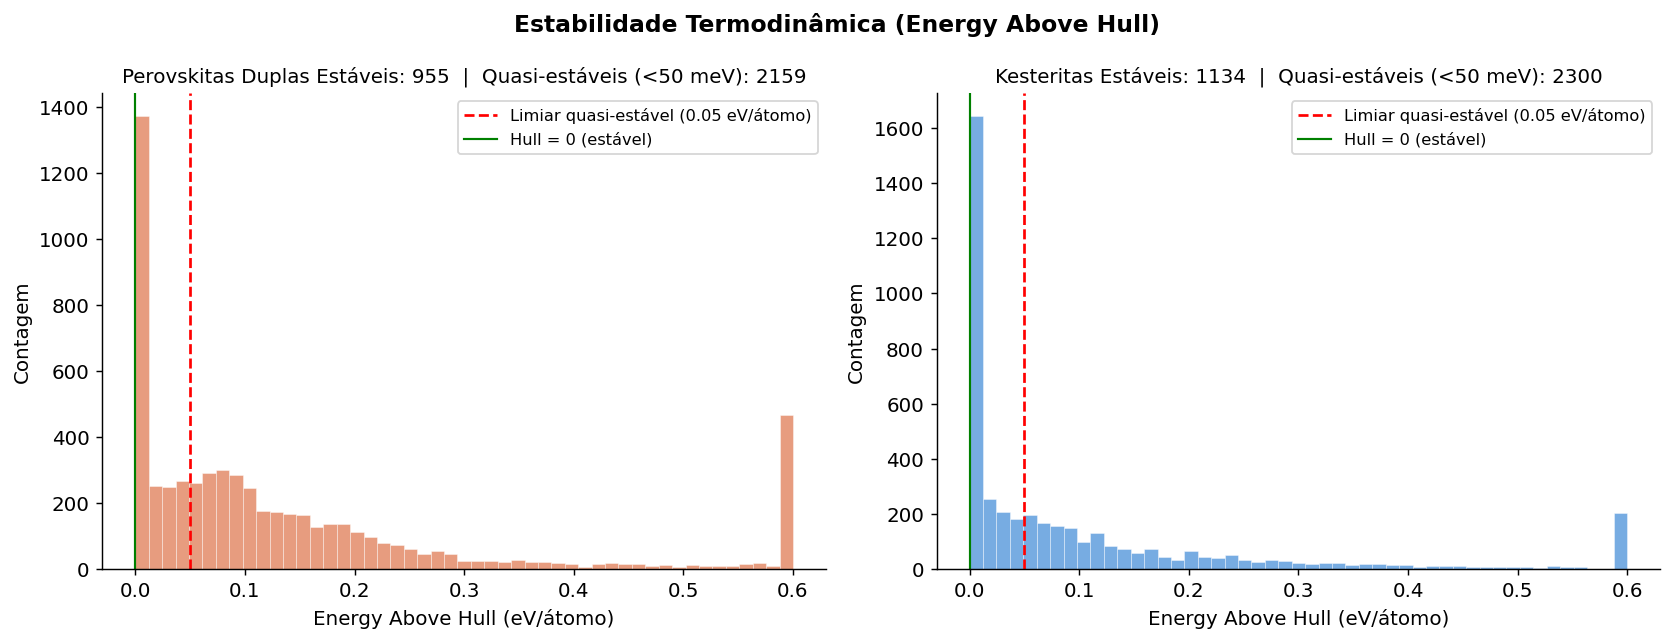

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [1, 1]})
fig.suptitle("Estabilidade Termodinâmica (Energy Above Hull)", fontsize=13, fontweight="bold")

bins = np.linspace(0, 0.6, 50)

for ax, (label, df, cor) in zip(axes, [
    ("Perovskitas Duplas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]):
    ax.hist(df["energy_above_hull"].clip(upper=0.6), bins=bins,
            color=cor, alpha=0.75, edgecolor="white", linewidth=0.3)

    # Limiar de quasi-estabilidade
    ax.axvline(HULL_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
               label=f"Limiar quasi-estável ({HULL_THRESHOLD} eV/átomo)")
    ax.axvline(0.0, color="green", linestyle="-", linewidth=1.2,
               label="Hull = 0 (estável)")

    n_estavel = (df["energy_above_hull"] == 0).sum()
    n_quasi   = (df["energy_above_hull"] < HULL_THRESHOLD).sum()
    ax.set_title(f"{label} Estáveis: {n_estavel}  |  Quasi-estáveis (<50 meV): {n_quasi}",
                 fontsize=11)
    ax.set_xlabel("Energy Above Hull (eV/átomo)", fontsize=11)
    ax.set_ylabel("Contagem", fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig2_estabilidade.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Energia de Formação × Band Gap

Este scatter é central na triagem: queremos materiais que simultaneamente tenham gap na janela de interesse **e** energia de formação negativa (formação exotérmica — o composto é mais estável que os elementos separados).

A cor dos pontos codifica a estabilidade termodinâmica via `energy_above_hull`. O quadrante ideal é o canto inferior direito dentro da faixa de gap desejada: formação muito negativa (estável quimicamente) e gap na janela PV ou IBSC.

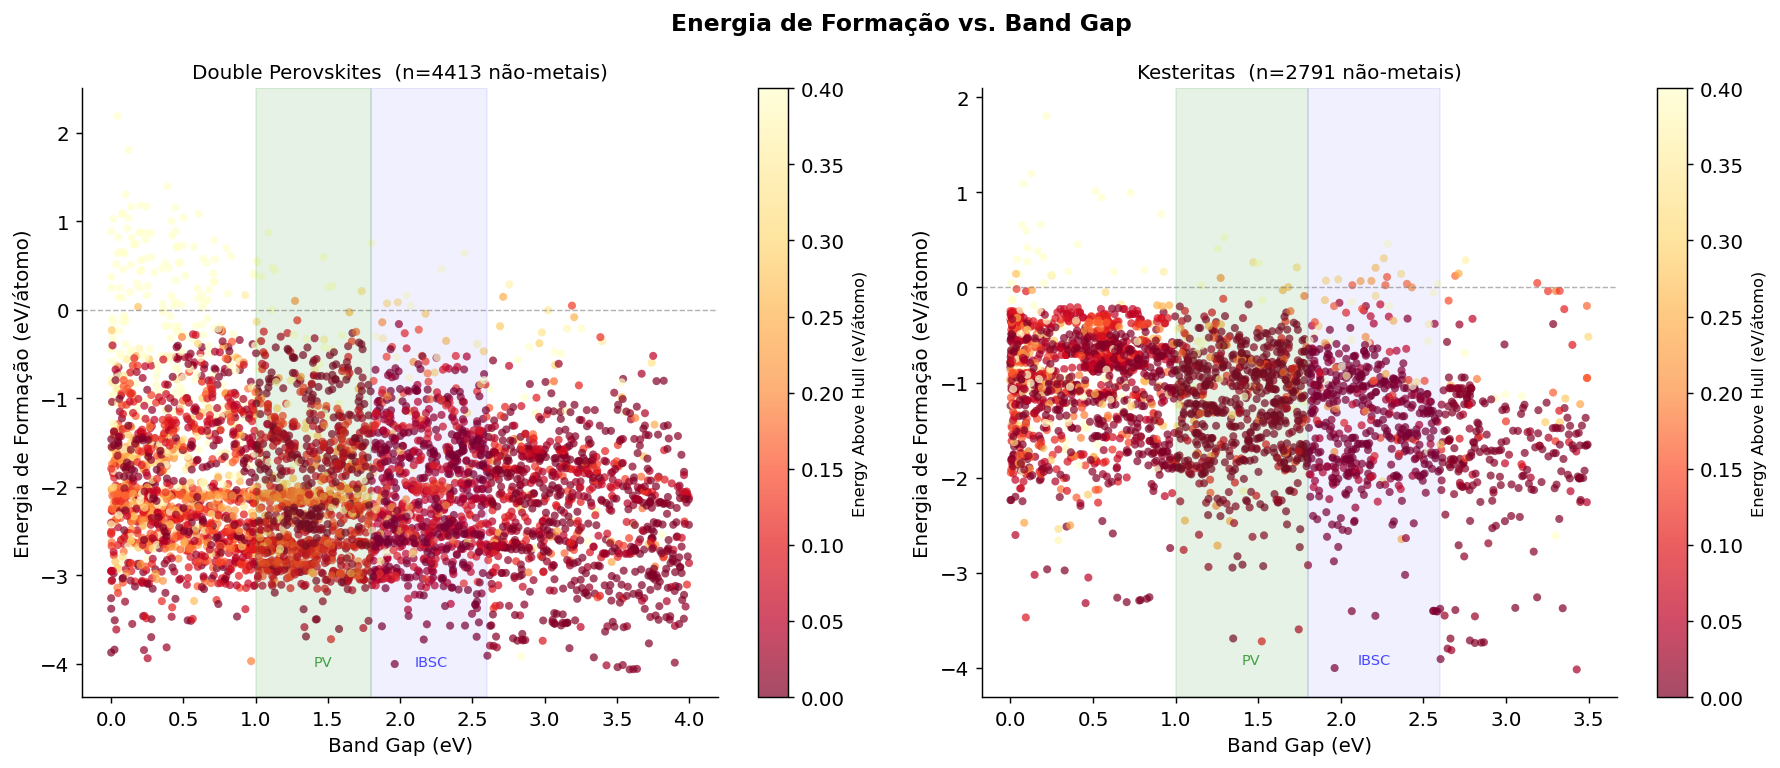

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Energia de Formação vs. Band Gap", fontsize=13, fontweight="bold")

for ax, (label, df, cor) in zip(axes, [
    ("Double Perovskites", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]):
    sub = df[~df["is_metal"]].dropna(
        subset=["band_gap", "formation_energy_per_atom", "energy_above_hull"]
    )

    sc = ax.scatter(
        sub["band_gap"],
        sub["formation_energy_per_atom"],
        c=sub["energy_above_hull"].clip(upper=0.5),
        cmap="YlOrRd_r", s=20, alpha=0.7,
        vmin=0, vmax=0.4, edgecolors="none",
    )
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Energy Above Hull (eV/átomo)", fontsize=9)

    # Faixas de gap
    ax.axvspan(PV_GAP_MIN, PV_GAP_MAX, alpha=0.10, color="green")
    ax.axvspan(PV_GAP_MAX, IBSC_GAP_MAX, alpha=0.06, color="blue")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)

    ax.set_xlabel("Band Gap (eV)", fontsize=11)
    ax.set_ylabel("Energia de Formação (eV/átomo)", fontsize=11)
    ax.set_title(f"{label}  (n={len(sub)} não-metais)", fontsize=11)

    # Anotar textos das faixas
    ax.text(1.4, ax.get_ylim()[0]*0.92, "PV", fontsize=8, color="green", alpha=0.7)
    ax.text(2.1, ax.get_ylim()[0]*0.92, "IBSC", fontsize=8, color="blue", alpha=0.7)

plt.tight_layout()
plt.savefig("fig3_formacao_vs_gap.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Distribuição por Sistema Cristalino

O sistema cristalino é uma feature categórica importante para ML — materiais com a mesma simetria tendem a compartilhar mecanismos de transporte e propriedades ópticas. Para double perovskites, esperamos predominância cúbica e tetragonal; kesteritas devem concentrar-se em tetragonal (o grupo espacial I-4 é o mais comum para CZTS).

In [17]:
df["crystal_system"].value_counts()

,count
crystal_system,
Monoclinic,1147
Trigonal,927
Orthorhombic,925
Triclinic,503
Tetragonal,406
Hexagonal,253
Cubic,206


In [18]:
'''sistemas_ordem = ["Cubic", "Tetragonal", "Orthorhombic",
                  "Hexagonal", "Trigonal", "Monoclinic", "Triclinic"]
vals = [ct.get(s, 0) for s in sistemas_ordem]
vals


NameError: name 'ct' is not defined

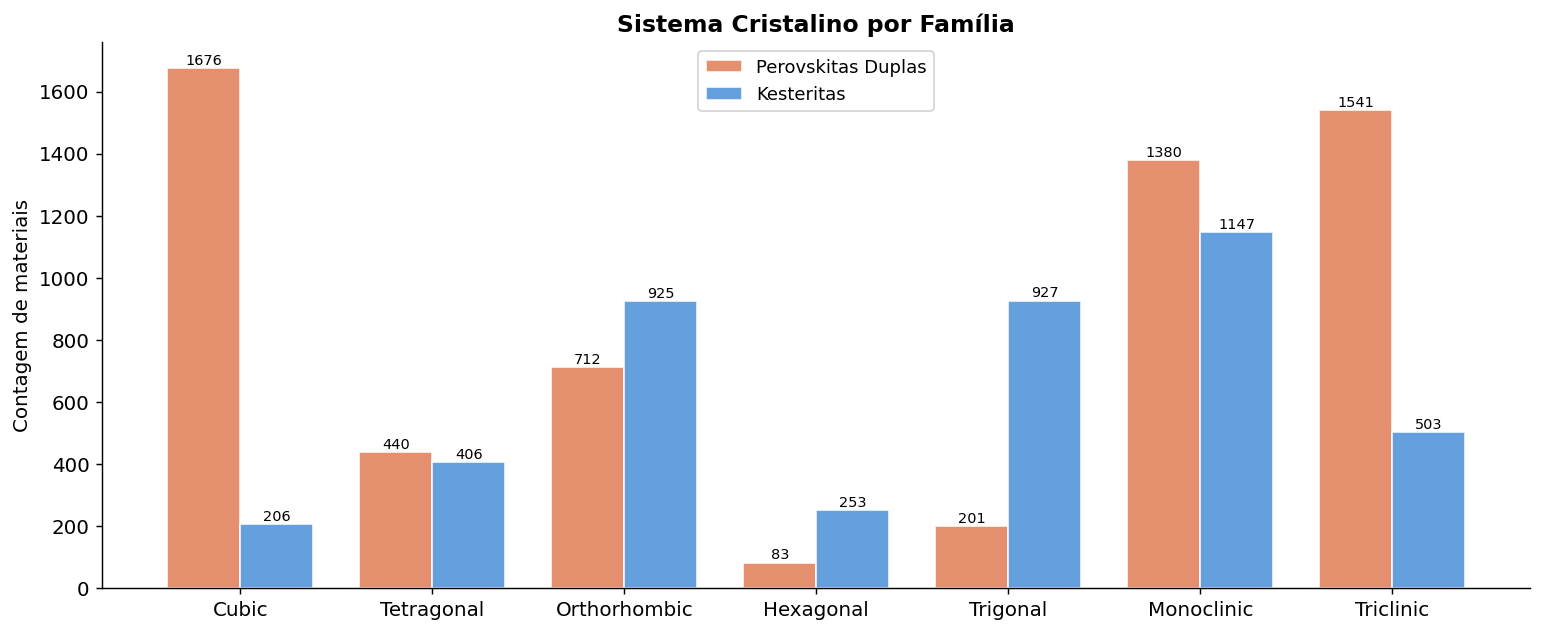

In [21]:
sistemas_ordem = ["Cubic", "Tetragonal", "Orthorhombic",
                  "Hexagonal", "Trigonal", "Monoclinic", "Triclinic"]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sistemas_ordem))
width = 0.38

for offset, (label, df, cor) in zip([-width/2, width/2], [
    ("Perovskitas Duplas", df_p, CORES["perovskita"]),
    ("Kesteritas",         df_k, CORES["kesterita"]),
]):
    ct = df["crystal_system"].value_counts()
    vals = [ct.get(s, 0) for s in sistemas_ordem]
    bars = ax.bar(x + offset, vals, width, label=label, color=cor, alpha=0.85,
                  edgecolor="white")
    # Anotar valores
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(v), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in sistemas_ordem], fontsize=11)
ax.set_ylabel("Contagem de materiais", fontsize=11)
ax.set_title("Sistema Cristalino por Família", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig4_sistemas_cristalinos.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.5 Mapa de Correlação entre Features

O heatmap de correlação de Pearson entre features numéricas revela:
- **Multicolinearidade** — pares altamente correlacionados que devem ser tratados antes de modelos lineares
- **Relações físicas** — ex: volume e nsites devem ser positivamente correlacionados; band_gap e densidade frequentemente têm correlação negativa (materiais mais densos tendem a ter maior delocalização eletrônica)
- **Features irrelevantes** — variáveis com correlação próxima de zero com o target (band_gap) podem ser removidas para simplificar o modelo

Plotamos os dois heatmaps lado a lado para comparar se as estruturas de correlação das duas famílias são similares ou distintas.

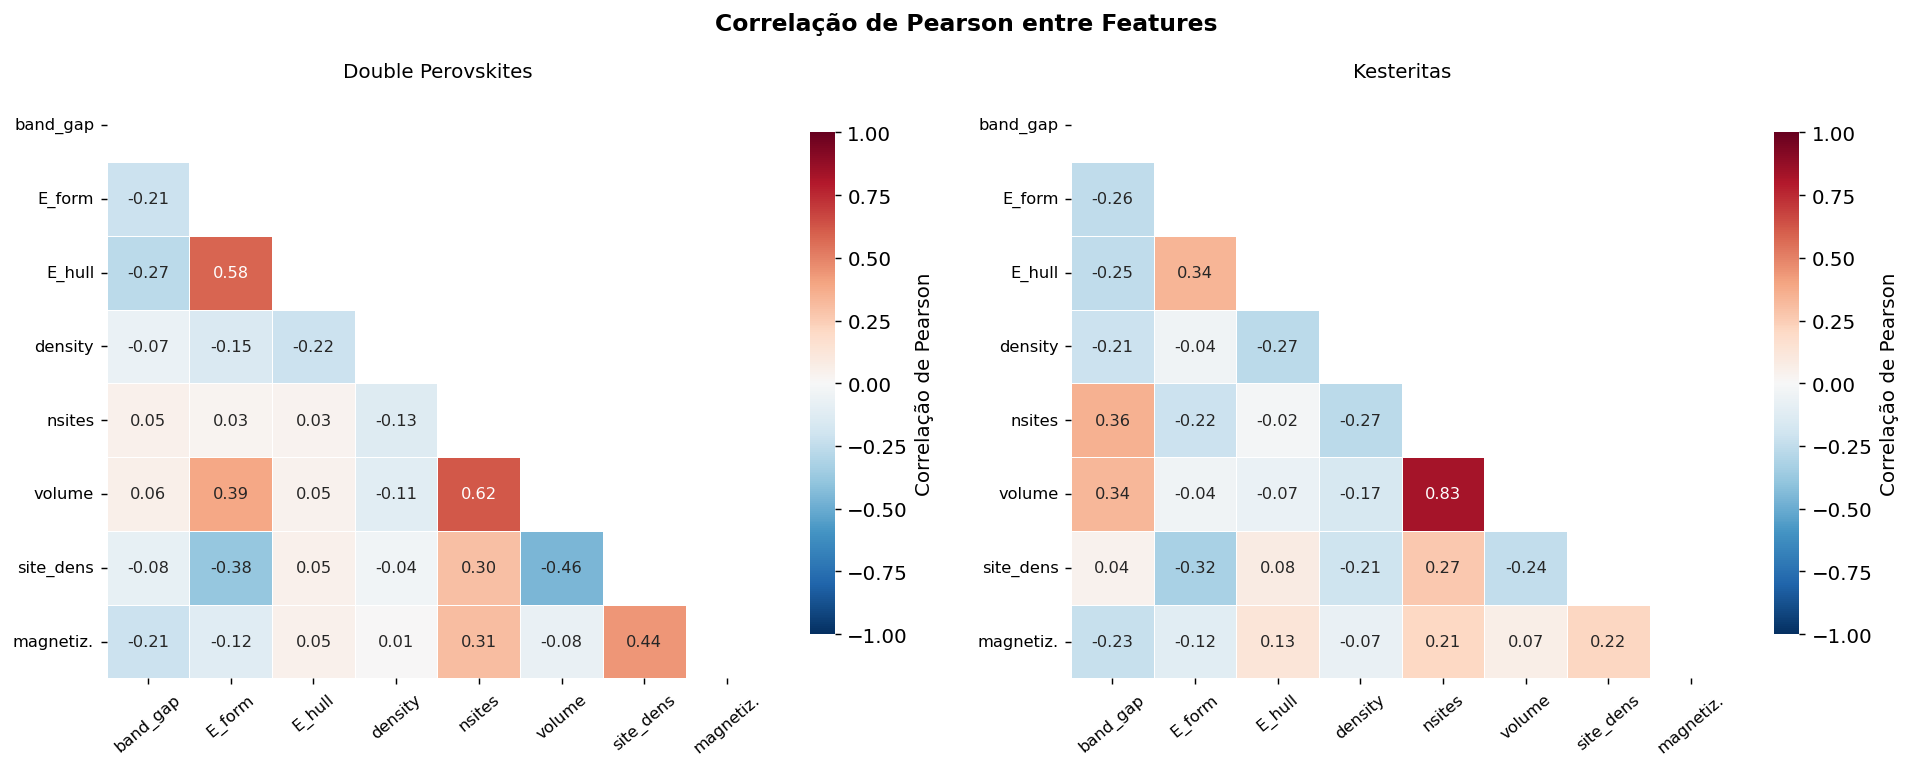

In [22]:
feat_corr = [
    "band_gap", "formation_energy_per_atom", "energy_above_hull",
    "density", "nsites", "volume", "site_density", "total_magnetization"
]
nomes_curtos = [
    "band_gap", "E_form", "E_hull",
    "density", "nsites", "volume", "site_dens", "magnetiz."
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Correlação de Pearson entre Features", fontsize=13, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("Double Perovskites", df_p),
    ("Kesteritas",         df_k),
]):
    corr = df[feat_corr].dropna().corr()
    corr.columns = nomes_curtos
    corr.index   = nomes_curtos
    mask = np.triu(np.ones_like(corr, dtype=bool))  # mostra apenas triângulo inferior
    sns.heatmap(
        corr, mask=mask, ax=ax,
        annot=True, fmt=".2f", annot_kws={"size": 9},
        cmap="RdBu_r", center=0, vmin=-1, vmax=1,
        linewidths=0.5,
        cbar_kws={"shrink": 0.85, "label": "Correlação de Pearson"},
    )
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig("fig5_correlacoes.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Identificação de Candidatos Promissores

Aplicamos um conjunto de critérios para identificar materiais que merecem investigação mais aprofundada. Os critérios são ordenados do mais restritivo ao mais flexível:

**Critério A — Candidato PV clássico (mais restritivo):**
1. Gap ∈ [1.0, 1.8] eV
2. Gap direto (sem necessidade de fônon na absorção)
3. Energia de formação negativa
4. Energy above hull < 50 meV/átomo

**Critério B — Candidato IBSC (janela estendida):**
1. Gap ∈ [1.8, 2.6] eV
2. Energia de formação negativa
3. Energy above hull < 100 meV/átomo

A separação em dois critérios é importante: candidatos IBSC precisariam de análise adicional de estrutura eletrônica (DOS projetada) para confirmar a existência de estados intermediários — mas a triagem inicial já reduz o espaço de busca dramaticamente.

In [23]:
def top_candidatos(df, criterio="pv", n=15):
    """Retorna os top-n candidatos segundo o critério especificado."""
    cols = ["material_id", "formula", "band_gap", "is_gap_direct",
            "energy_above_hull", "formation_energy_per_atom",
            "crystal_system", "spacegroup_symbol", "density"]

    if criterio == "pv":
        filtro = (
            df["is_pv_candidate"] &
            df["is_gap_direct"] &
            (df["formation_energy_per_atom"] < 0) &
            (df["energy_above_hull"] < HULL_THRESHOLD)
        )
    elif criterio == "ibsc":
        filtro = (
            df["is_ibsc_candidate"] &
            (df["formation_energy_per_atom"] < 0) &
            (df["energy_above_hull"] < 0.10)
        )
    else:
        raise ValueError("Critério deve ser 'pv' ou 'ibsc'")

    resultado = (
        df[filtro]
        .sort_values(["energy_above_hull", "band_gap"])
        .head(n)[cols]
        .reset_index(drop=True)
    )
    return resultado


# ── Candidatos PV ─────────────────────────────────────────────────────────────
print("=" * 68)
print("TOP CANDIDATOS PV — DOUBLE PEROVSKITES (gap direto + hull < 50 meV)")
print("=" * 68)
top_pv_p = top_candidatos(df_p, "pv", n=15)
print(top_pv_p.to_string(index=False) if len(top_pv_p) else "Nenhum com critério rígido.")

print("\n" + "=" * 68)
print("TOP CANDIDATOS PV — KESTERITAS (gap direto + hull < 50 meV)")
print("=" * 68)
top_pv_k = top_candidatos(df_k, "pv", n=15)
print(top_pv_k.to_string(index=False) if len(top_pv_k) else "Nenhum com critério rígido.")

TOP CANDIDATOS PV — DOUBLE PEROVSKITES (gap direto + hull < 50 meV)
material_id      formula  band_gap  is_gap_direct  energy_above_hull  formation_energy_per_atom crystal_system spacegroup_symbol  density
 mp-1112544    Cs2TlAsI6    1.0046           True                0.0                  -1.059115          Cubic             Fm-3m 4.531965
 mp-1114011   Rb2NaTlBr6    1.0102           True                0.0                  -1.528904          Cubic             Fm-3m 3.943709
  mp-632724  ReH8(NCl3)2    1.0107           True                0.0                  -0.889937          Cubic             Fm-3m 2.874959
  mp-643735  H8Pd(NCl3)2    1.0278           True                0.0                  -0.822487     Monoclinic            P2_1/c 2.481977
 mp-1219602  Rb4InSbCl12    1.0336           True                0.0                  -1.806341     Tetragonal            P4/mmm 2.932611
  mp-569413 K2Sr(NbCl3)6    1.0688           True                0.0                  -1.920303       Tr

In [24]:
# ── Candidatos IBSC ───────────────────────────────────────────────────────────
print("=" * 68)
print("TOP CANDIDATOS IBSC — DOUBLE PEROVSKITES (gap 1.8–2.6 eV)")
print("=" * 68)
top_ibsc_p = top_candidatos(df_p, "ibsc", n=15)
print(top_ibsc_p.to_string(index=False) if len(top_ibsc_p) else "Nenhum encontrado.")

print("\n" + "=" * 68)
print("TOP CANDIDATOS IBSC — KESTERITAS (gap 1.8–2.6 eV)")
print("=" * 68)
top_ibsc_k = top_candidatos(df_k, "ibsc", n=15)
print(top_ibsc_k.to_string(index=False) if len(top_ibsc_k) else "Nenhum encontrado.")

TOP CANDIDATOS IBSC — DOUBLE PEROVSKITES (gap 1.8–2.6 eV)
material_id      formula  band_gap  is_gap_direct  energy_above_hull  formation_energy_per_atom crystal_system spacegroup_symbol  density
 mp-1228886      CsVFeF6    1.8140           True                0.0                  -3.014621   Orthorhombic              Imma 3.865640
  mp-555212    Ba2InBrO3    1.8237          False                0.0                  -2.561334     Tetragonal            P4/nmm 5.867766
  mp-996944   Cs2TlInBr6    1.8255          False                0.0                  -1.577040          Cubic             Fm-3m 4.301131
   mp-18518  Rb2NaMn3F12    1.8271          False                0.0                  -2.939748      Triclinic               P-1 3.652050
 mp-1226043     CsFeCoF6    1.8280          False                0.0                  -2.679923   Orthorhombic              Imma 4.081345
  mp-572728    CsV2I3O13    1.8297           True                0.0                  -1.502475   Orthorhombic    

### 8.1 Visualização dos Candidatos — Scatter Anotado

Este gráfico foca apenas nos materiais que passaram pelos filtros de candidatos PV e IBSC. Os mais estáveis (menor energy_above_hull) são anotados com suas fórmulas — esses são os materiais que valem aprofundamento na próxima fase da pesquisa.

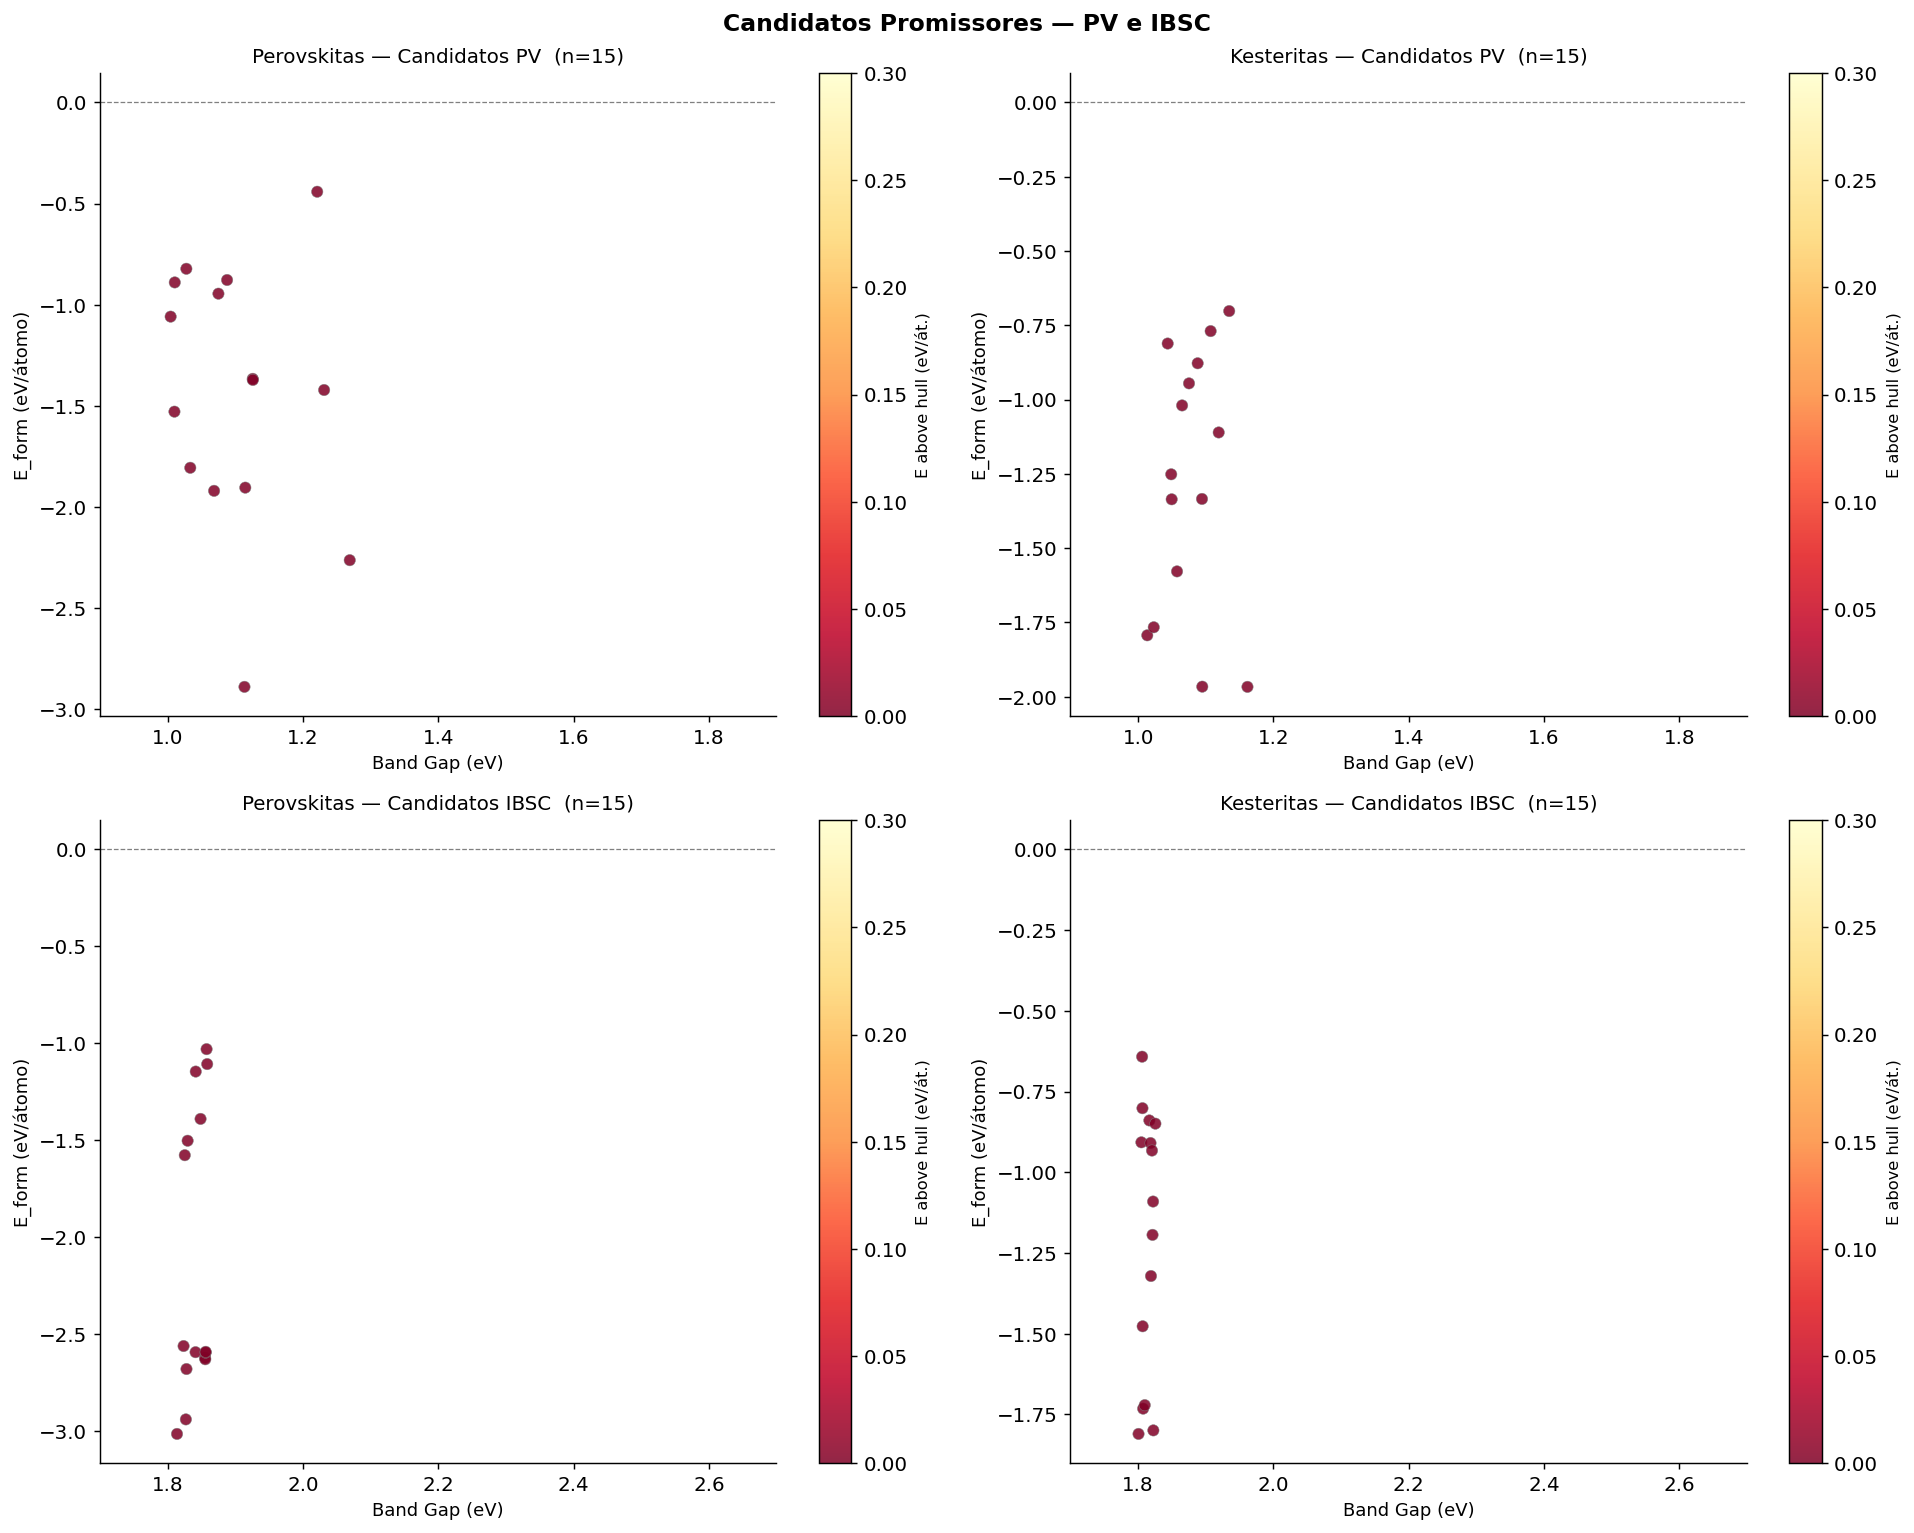

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Candidatos Promissores — PV e IBSC", fontsize=13, fontweight="bold")

pares = [
    (axes[0,0], "Perovskitas — Candidatos PV",   top_pv_p, "pv"),
    (axes[0,1], "Kesteritas — Candidatos PV",    top_pv_k, "pv"),
    (axes[1,0], "Perovskitas — Candidatos IBSC", top_ibsc_p, "ibsc"),
    (axes[1,1], "Kesteritas — Candidatos IBSC",  top_ibsc_k, "ibsc"),
]

for ax, titulo, sub, criterio in pares:
    # `sub` já contém os candidatos top filtrados por `top_candidatos`
    # xmin e xmax são para a janela do plot, não para filtrar `sub`
    if criterio == "pv":
        xmin, xmax = PV_GAP_MIN - 0.1, PV_GAP_MAX + 0.1
    else:
        xmin, xmax = PV_GAP_MAX - 0.1, IBSC_GAP_MAX + 0.1

    sub = sub.dropna(subset=["band_gap","formation_energy_per_atom","energy_above_hull"])

    if len(sub) == 0:
        ax.text(0.5, 0.5, "Sem candidatos", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(titulo, fontsize=11)
        continue

    sc = ax.scatter(
        sub["band_gap"],
        sub["formation_energy_per_atom"],
        c=sub["energy_above_hull"].clip(upper=0.3), # Clip para melhor visualização da colorbar
        cmap="YlOrRd_r", s=40, alpha=0.85,
        vmin=0, vmax=0.3,
        edgecolors="gray", linewidths=0.3,
    )
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("E above hull (eV/át.)", fontsize=9)

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Band Gap (eV)", fontsize=10)
    ax.set_ylabel("E_form (eV/átomo)", fontsize=10)
    ax.set_title(f"{titulo}  (n={len(sub)})", fontsize=11)
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")

plt.tight_layout()
plt.savefig("fig6_candidatos_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Exportação dos Dados

Exportamos quatro arquivos CSV para uso nas próximas fases de análise:
- `double_perovskites_raw.csv` — todos os dados brutos das perovskitas
- `kesteritas_raw.csv` — todos os dados brutos das kesteritas
- `candidatos_pv.csv` — candidatos PV de ambas as famílias (critério rígido)
- `candidatos_ibsc.csv` — candidatos IBSC de ambas as famílias

Esses arquivos são o ponto de partida para a fase 2: construção de descritores composicionais avançados (Magpie, Matminer) e treinamento de modelos preditivos.

In [ ]:
# Dados brutos
df_p.to_csv("double_perovskitas_raw.csv", index=False)
df_k.to_csv("kesteritas_raw.csv",         index=False)

# Candidatos PV (ambas as famílias)
cand_pv = pd.concat([
    top_pv_p.assign(familia="Double Perovskite"),
    top_pv_k.assign(familia="Kesterita"),
], ignore_index=True)
cand_pv.to_csv("candidatos_pv.csv", index=False)

# Candidatos IBSC
cand_ibsc = pd.concat([
    top_ibsc_p.assign(familia="Double Perovskite"),
    top_ibsc_k.assign(familia="Kesterita"),
], ignore_index=True)
cand_ibsc.to_csv("candidatos_ibsc.csv", index=False)

print("Arquivos exportados:")
print(f"  double_perovskitas_raw.csv  — {len(df_p)} materiais")
print(f"  kesteritas_raw.csv          — {len(df_k)} materiais")
print(f"  candidatos_pv.csv           — {len(cand_pv)} candidatos PV")
print(f"  candidatos_ibsc.csv         — {len(cand_ibsc)} candidatos IBSC")

## 10. Próximos Passos

Com a EDA concluída e os candidatos identificados, a trajetória natural do artigo segue em duas direções:

### Fase 2 — Descritores composicionais (Matminer / Magpie)
Substituir as features brutas (density, nsites, volume) por descritores físico-químicos derivados da composição elementar — médias ponderadas de eletronegatividade, raio atômico, energia de ionização, etc. Isso é feito com a biblioteca `matminer`:

```python
from matminer.featurizers.composition import ElementProperty
ep = ElementProperty.from_preset("magpie")
df["composition"] = df["formula"].apply(Composition)
df = ep.featurize_dataframe(df, "composition")
```

### Fase 3 — Modelos preditivos
- **Regressão de band gap** com Random Forest / XGBoost + análise de importância (SHAP)
- **Classificação de estabilidade** (estável vs. meta-estável)
- **Validação cruzada** com split composicional (não aleatório) para evitar data leakage

### Fase 4 — Análise de estrutura eletrônica dos candidatos finais
Para os materiais mais promissores, acessar o endpoint `electronic_structure` do Materials Project para examinar a DOS projetada e verificar a presença de estados dentro do gap — confirmação computacional do mecanismo de banda intermediária.

```python
with MPRester(MP_API_KEY) as mpr:
    bs = mpr.get_bandstructure_by_material_id("mp-XXXXX")
    dos = mpr.get_dos_by_material_id("mp-XXXXX")
```
